In [1]:
import matplotlib.pyplot as plt
from core.utils import load_run_data
import jax.numpy as jnp
import pandas as pd

def plot_rl_results(data_dict, title="Training Performance", y_label = "Discounted Episode Returns"):
    """
    Plots multiple RL runs with optional smoothing.
    
    Args:
        data_dict: Dictionary mapping Label -> Array of returns
        title: Plot title/
    """
    plt.figure(figsize=(5, 5))
    
    # Use a clean style
    plt.style.use('seaborn-v0_8-paper') 
    
    for label, values in data_dict.items():
        # Ensure values are averaged across seeds if multi-dimensional
        y = values.mean(0) if values.ndim > 1 else values

        plt.plot(y, label=label, linewidth=2)

    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Episodes", fontsize=10)
    plt.ylabel(y_label, fontsize=10)
    plt.legend(frameon=True, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
def create_metrics_table(runs_dict, metrics_list, bps_metrics, agg_method="final", x=10):
    """
    Creates a table comparing different algorithms across a list of metrics.
    
    Args:
        runs_dict: Dictionary mapping algorithm name to its metrics dictionary.
                   e.g., {"LSTD": lstd_metrics, "BR": br_metrics}
        metrics_list: List of metric keys to include in the table.
        agg_method: How to aggregate the time-series data. "final" takes the 
                    last step, "mean" averages over the entire training run.
    
    Returns:
        pd.DataFrame containing the formatted table.
    """
    table_data = []

    for algo_name, metrics in runs_dict.items():
        row = {"Algorithm": algo_name}
        for metric in metrics_list:
            if metric in metrics:
                data = jnp.asarray(metrics[metric])
                # Mean across seeds if multi-seed data
                if data.ndim > 1:
                    data = data.mean(axis=0)
                # Aggregate over time
                if data.size > 0:
                    if agg_method == 'final':
                        val = float(data[-1]) 
                    elif agg_method == 'mean':
                        val = float(data.mean())
                    elif agg_method == 'last_x_mean':
                        val = float(data[-x:].mean())
                else:
                    val = None
            else:
                val = None
        
            if metric in bps_metrics:
                row[f"{metric} (bps)"] = val * 10000.0
            else:
                row[metric] = val

        table_data.append(row)
        
    df = pd.DataFrame(table_data)
    df.set_index("Algorithm", inplace=True)
    return df


### Comparison of Linear Methods

In [2]:
metrics_list = ['nn_weighted_VE', 'nn_greedy_correct', 'nn_lstd_diff', 'nn_weighted_PBE']
basis_point_metrics = ['nn_weighted_VE','nn_lstd_diff', 'nn_weighted_PBE']

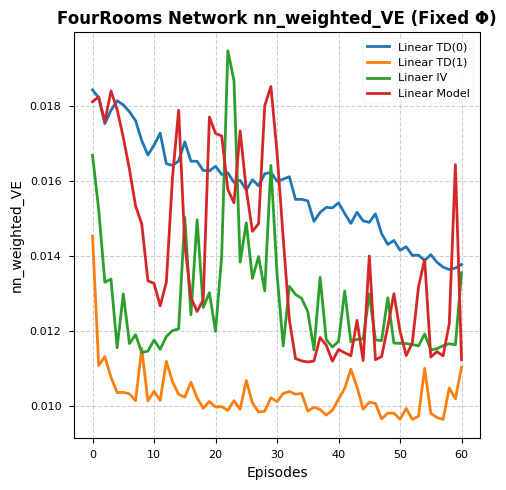

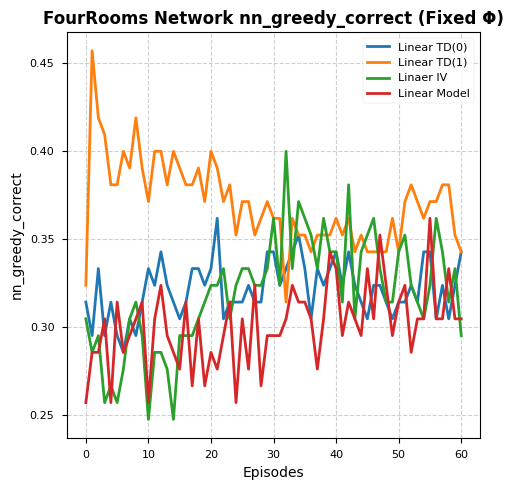

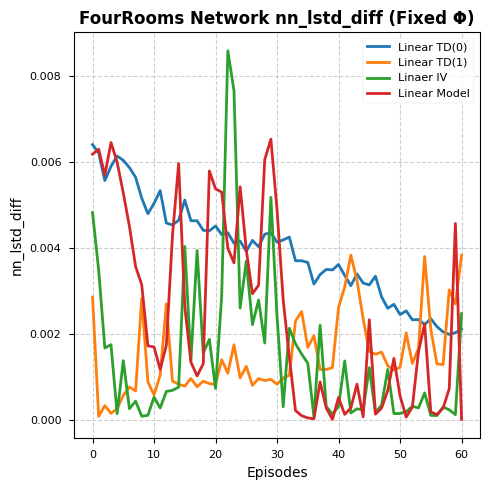

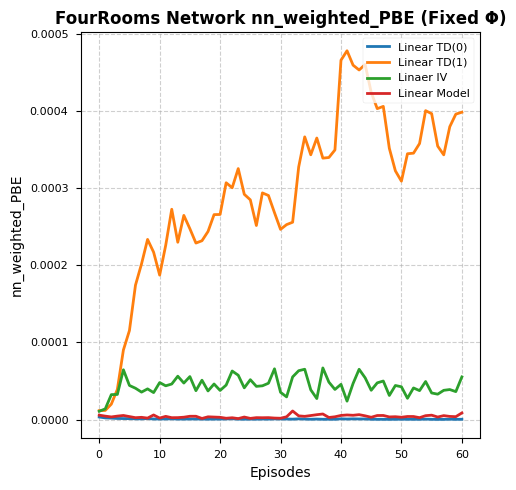

,nn_weighted_VE (bps),nn_greedy_correct,nn_lstd_diff (bps),nn_weighted_PBE (bps)
Algorithm,,,,
Linear TD(0),138.831502,0.323810,22.138695,0.004652
Linear TD(1),101.074427,0.368571,23.067789,3.715458
Linaer IV,118.256221,0.326667,4.753832,0.391851
Linear Model,124.031575,0.313333,10.086594,0.046811


In [3]:
# random_td_config, random_td_metrics = load_run_data("random_td/20260514_162117", 'FourRooms-misc', 'results')
random_td_config, random_td_metrics = load_run_data("random_linear_td/20260522_104723", 'FourRooms-misc', 'results')
random_mc, random_mc_metrics = load_run_data("random_linear_mc/20260522_104603", 'FourRooms-misc', 'results')
random_iv_config, random_iv_metrics = load_run_data("random_policy_linear_z/20260522_104822", 'FourRooms-misc', 'results')
random_model_config, random_model_metrics = load_run_data("random_policy_linear_model/20260522_104934", 'FourRooms-misc', 'results')

runs_dict = {
    "Linear TD(0)": random_td_metrics,
    "Linear TD(1)": random_mc_metrics,
    'Linaer IV': random_iv_metrics,
    'Linear Model': random_model_metrics
    
}
for metric in metrics_list:
    runs = {k: v[metric] for k,v in runs_dict.items()}
    plot_rl_results(runs, title=f"FourRooms Network {metric} (Fixed Φ)", y_label = metric)


# 4. Generate the table
# Use agg_method="mean" if you want the average over the whole run instead
df = create_metrics_table(runs_dict, metrics_list, basis_point_metrics, agg_method="last_x_mean")

# Display the table (in a Jupyter Notebook, simply outputting 'df' renders a nice HTML table)
df

### Now Progress to Learned Features
- For IV and Model, Φ is learned with MC, where the weights are frozen
- For MC, Φ and w are learned with MC
- For TD, Φ and w are learned with TD(0)

### What features to learn? TD(0) or MC?
Let's see which is more effective for two timescale LSTD learning, where the LSTD(0) solution is used to override the final critic weights.

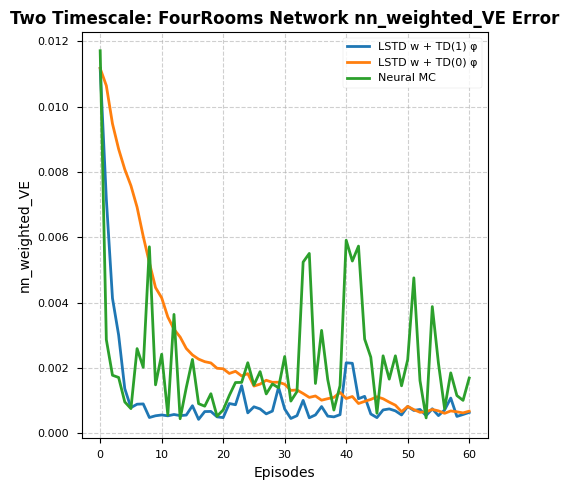

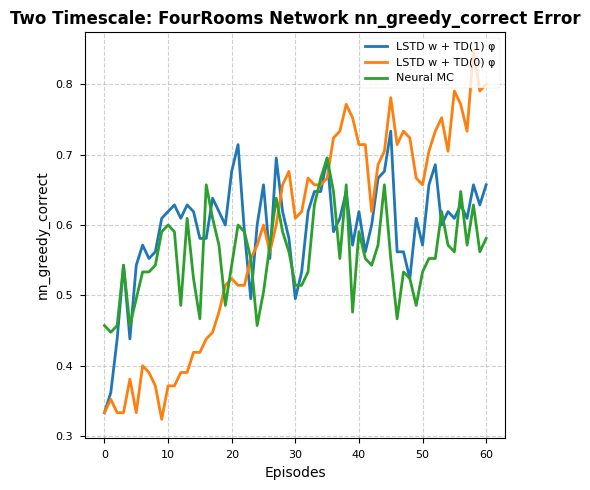

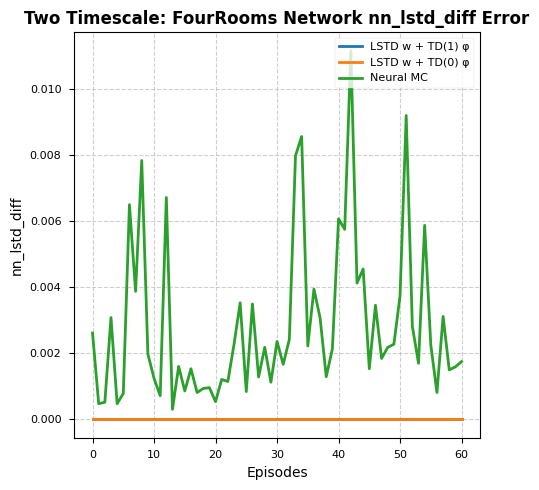

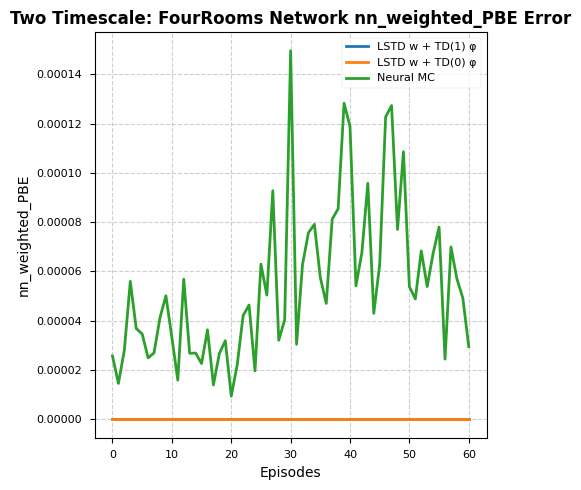

,nn_weighted_VE (bps),nn_greedy_correct,nn_lstd_diff (bps),nn_weighted_PBE (bps)
Algorithm,,,,
LSTD w + TD(1) φ,6.810392,0.635238,0.000000,2.237937e-12
LSTD w + TD(0) φ,6.725030,0.762857,0.000000,6.189041e-11
Neural MC,19.344013,0.584762,30.606315,5.467276e-01


In [56]:
# random_td_config, random_td_metrics = load_run_data("random_td/20260514_162117", 'FourRooms-misc', 'results')
lstd_1_config, lstd_1_metrics = load_run_data("random_lstd/mc", 'FourRooms-misc', 'results')
random_mc, random_mc_metrics = load_run_data("random_td/mc", 'FourRooms-misc', 'results')
random_td, random_td_metrics = load_run_data("random_td/td0", 'FourRooms-misc', 'results')
random_td_06, random_td_06_metrics = load_run_data("random_td/td_06", 'FourRooms-misc', 'results')
lstd_0_config, lstd_0_metrics = load_run_data("random_lstd/td0", 'FourRooms-misc', 'results')
lstd_06_config, lstd_06_metrics = load_run_data("random_lstd/td_06", 'FourRooms-misc', 'results')

runs_dict = {
    "LSTD w + TD(1) φ": lstd_1_metrics,
    "LSTD w + TD(0) φ": lstd_0_metrics,
    'Neural MC': random_mc_metrics,   
}

for metric in metrics_list:
    runs = {k: v[metric] for k,v in runs_dict.items()}
    plot_rl_results(runs, title=f"Two Timescale: FourRooms Network {metric} Error", y_label = metric)

df = create_metrics_table(runs_dict, metrics_list, basis_point_metrics, agg_method="last_x_mean")
df

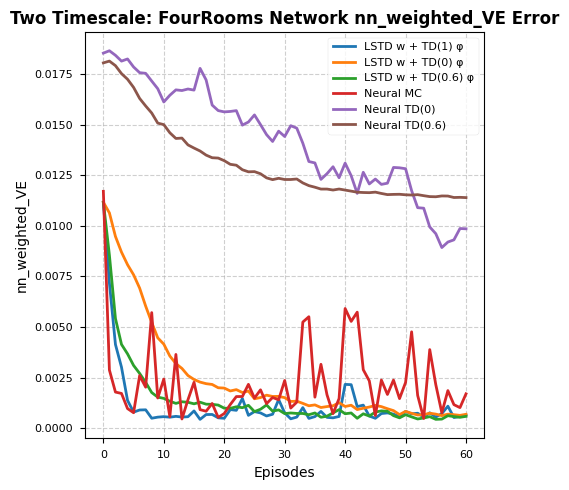

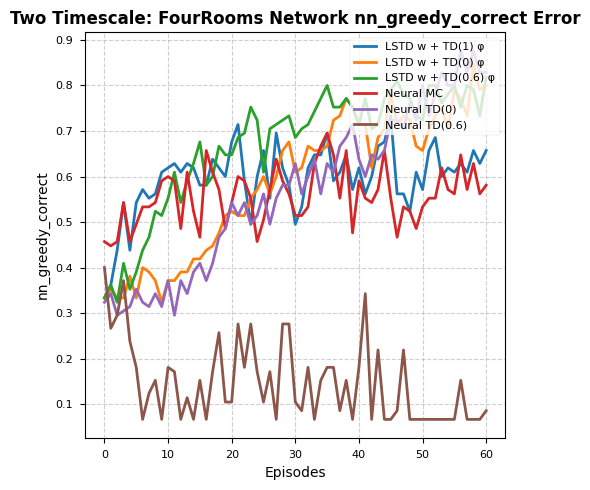

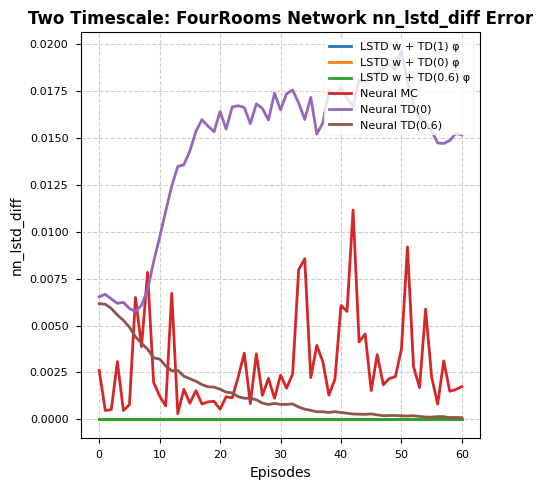

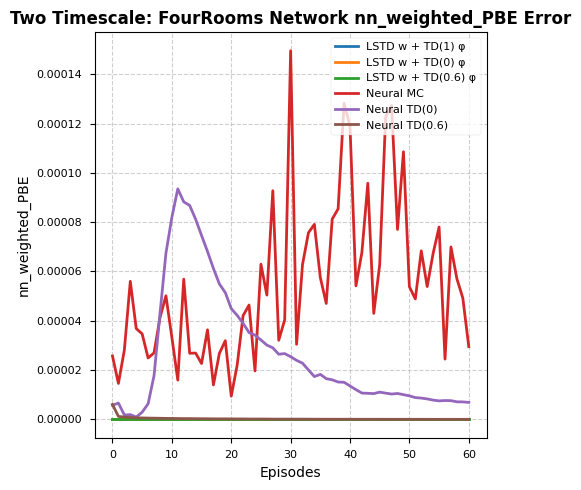

,nn_weighted_VE (bps),nn_greedy_correct,nn_lstd_diff (bps),nn_weighted_PBE (bps)
Algorithm,,,,
LSTD w + TD(1) φ,6.810392,0.635238,0.000000,2.237937e-12
LSTD w + TD(0) φ,6.725030,0.762857,0.000000,6.189041e-11
LSTD w + TD(0.6) φ,5.222698,0.783810,0.000000,1.941840e-10
Neural MC,19.344013,0.584762,30.606315,5.467276e-01
Neural TD(0),100.253047,0.818095,156.748984,7.744969e-02
Neural TD(0.6),114.636784,0.077143,1.361538,1.623504e-04


In [57]:
# random_td_config, random_td_metrics = load_run_data("random_td/20260514_162117", 'FourRooms-misc', 'results')
lstd_1_config, lstd_1_metrics = load_run_data("random_lstd/mc", 'FourRooms-misc', 'results')
random_mc, random_mc_metrics = load_run_data("random_td/mc", 'FourRooms-misc', 'results')
random_td, random_td_metrics = load_run_data("random_td/td0", 'FourRooms-misc', 'results')
random_td_06, random_td_06_metrics = load_run_data("random_td/td_06", 'FourRooms-misc', 'results')
lstd_0_config, lstd_0_metrics = load_run_data("random_lstd/td0", 'FourRooms-misc', 'results')
lstd_06_config, lstd_06_metrics = load_run_data("random_lstd/td_06", 'FourRooms-misc', 'results')

runs_dict = {
    "LSTD w + TD(1) φ": lstd_1_metrics,
    "LSTD w + TD(0) φ": lstd_0_metrics,
    "LSTD w + TD(0.6) φ": lstd_06_metrics,
    'Neural MC': random_mc_metrics,   
    'Neural TD(0)': random_td_metrics,   
    'Neural TD(0.6)': random_td_06_metrics,   
}

for metric in metrics_list:
    runs = {k: v[metric] for k,v in runs_dict.items()}
    plot_rl_results(runs, title=f"Two Timescale: FourRooms Network {metric} Error", y_label = metric)

df = create_metrics_table(runs_dict, metrics_list, basis_point_metrics, agg_method="last_x_mean")
df

In [ ]:
# random_td_config, random_td_metrics = load_run_data("random_td/20260514_162117", 'FourRooms-misc', 'results')
random_mc, random_mc_metrics = load_run_data("random_td/mc", 'FourRooms-misc', 'results')
# random_mc, random_mc_metrics = load_run_data("random_linear_mc/20260522_104603", 'FourRooms-misc', 'results')
random_iv_config, random_iv_metrics = load_run_data("random_policy_fixed_z_mc_phi/20260522_144639", 'FourRooms-misc', 'results')
random_model_config, random_model_metrics = load_run_data("random_policy_linear_model_mc_feats/20260522_135333", 'FourRooms-misc', 'results')

for metric in ['nn_weighted_VE', 'nn_greedy_correct', 'nn_lstd_diff', 'nn_weighted_PBE']:
    runs = {'TD(0)': random_td_metrics[metric],'TD(1)': random_mc_metrics[metric],'IV': random_iv_metrics[metric], 'Linear Model': random_model_metrics[metric]}
    plot_rl_results(runs, title=f"FourRooms Network {metric} Error (Fixed Φ)", y_label = metric)

KeyError: 'nn_weighted_VE'

### Now Progress to "Deep Instrument"
- For IV, Φ is learned with MC (w is frozen). Z has gradient from L1 and L2.
<!-- random_policy_live_z_mc_phi/20260522_144304 -->

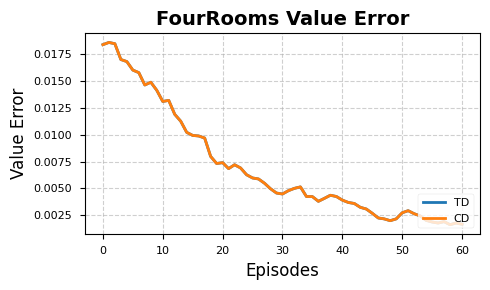

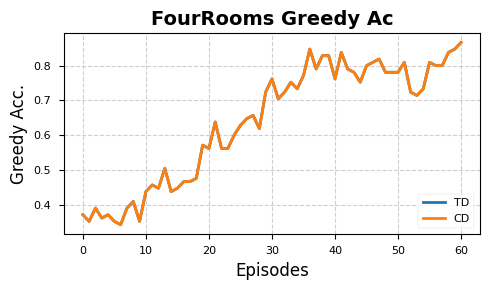

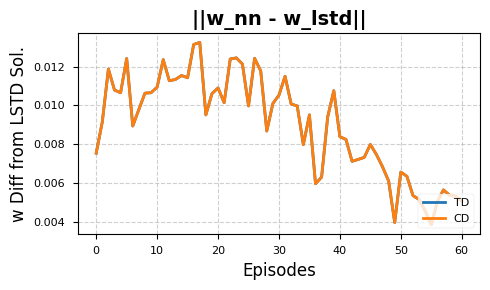

In [7]:
td_config, td_metrics = load_run_data("random_td/no_interfering_factors", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/no_interfering_factors", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

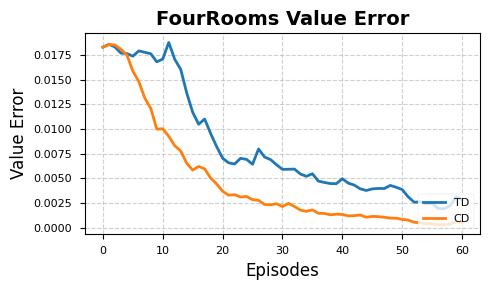

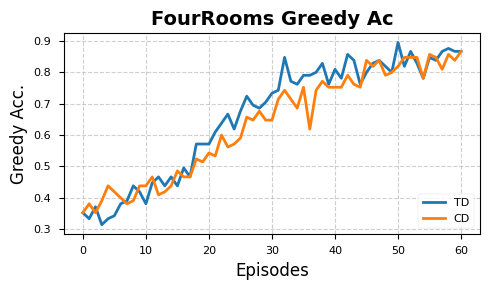

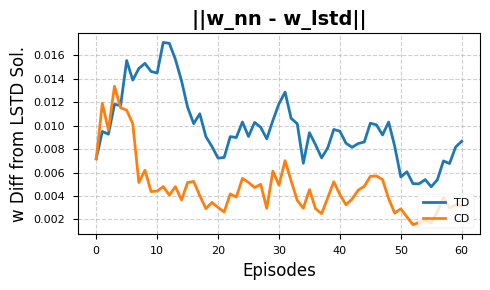

In [5]:
td_config, td_metrics = load_run_data("random_td/20260513_163216", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/20260513_150359", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

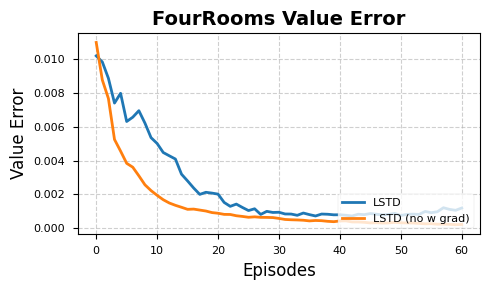

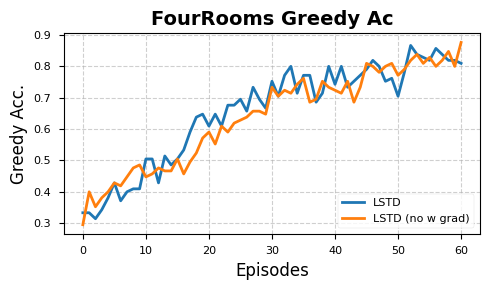

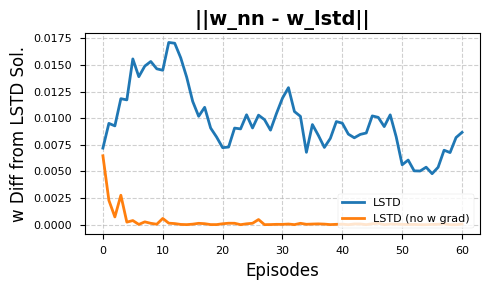

In [52]:
lstd_config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
lstd_cd_config, lstd_cd_metrics = load_run_data("random_lstd/20260513_154513", 'FourRooms-misc', 'results')
lstd_nw_config, lstd_nw_metrics = load_run_data("random_lstd/20260513_160625", 'FourRooms-misc', 'results')

runs = {'LSTD': td_metrics['LSTD_weighted_VE'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'LSTD': td_metrics['LSTD_greedy_correct'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'LSTD': td_metrics['nn_lstd_diff'], 'LSTD (no w grad)': lstd_nw_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

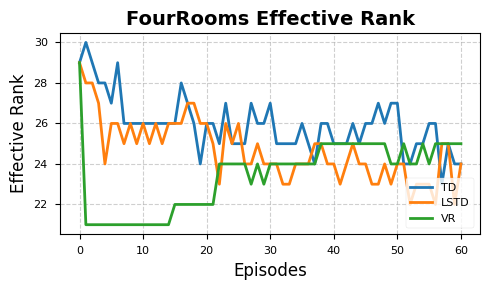

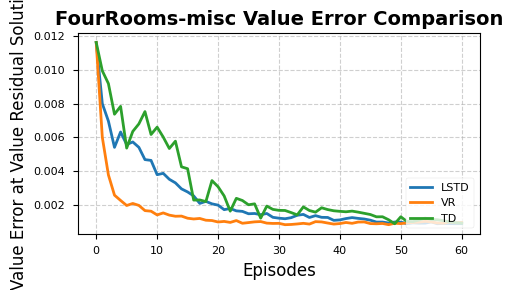

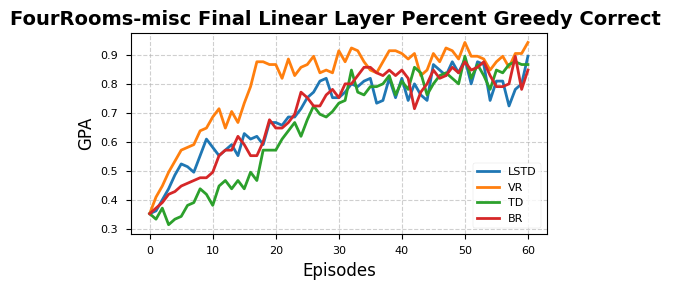

In [38]:
td_config, td_metrics = load_run_data("random_td/20260511_144250", 'FourRooms-misc', 'results')
config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
config, vr_metrics = load_run_data("random_vr/20260511_145817", 'FourRooms-misc', 'results')
config, br_metrics = load_run_data("random_br/20260511_145516", 'FourRooms-misc', 'results')

runs = {
    "TD": td_metrics['effective_rank'],
    "LSTD": lstd_metrics['effective_rank'],
    "VR": vr_metrics['effective_rank'],
    # "BR": br_metrics['effective_rank']
}
plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

runs = {
    "LSTD": lstd_metrics['VR_uniform_VE'],
    "VR": vr_metrics['VR_uniform_VE'],
    "TD": td_metrics['VR_uniform_VE'],
    # "BR": br_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")

runs = {
    "LSTD": lstd_metrics['nn_greedy_correct'],
    "VR": vr_metrics['nn_greedy_correct'],
    "TD": td_metrics['nn_greedy_correct'],
    "BR": br_metrics['nn_greedy_correct']
}

plot_rl_results(runs, title="FourRooms-misc Final Linear Layer Percent Greedy Correct ", y_label = "GPA")

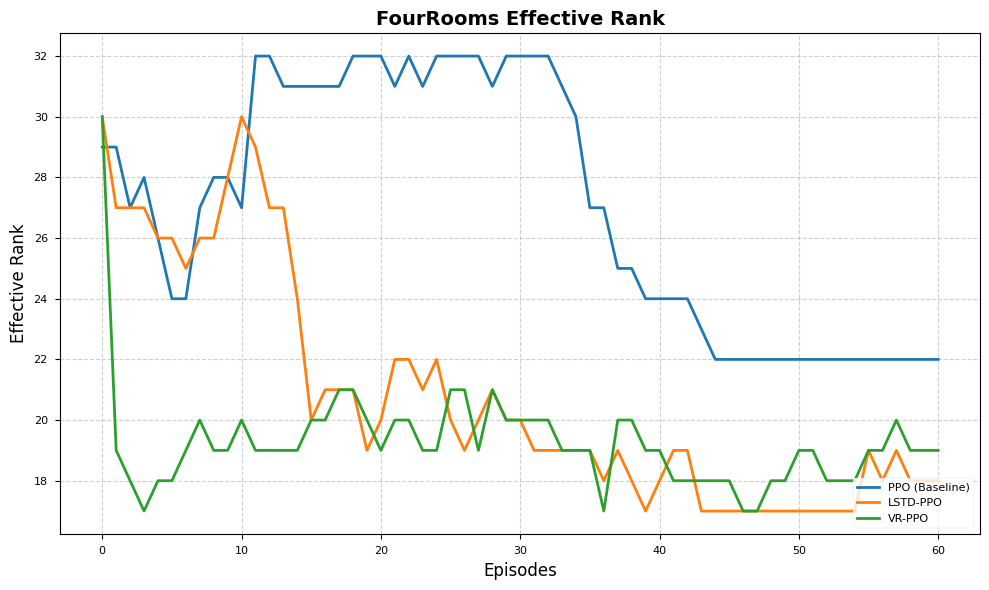

In [ ]:

runs = {
    "PPO (Baseline)": metrics['effective_rank'],
    "LSTD-PPO": lstd_ppo_metrics['effective_rank'],
    "VR-PPO": vr_ppo_metrics['effective_rank']
}

plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

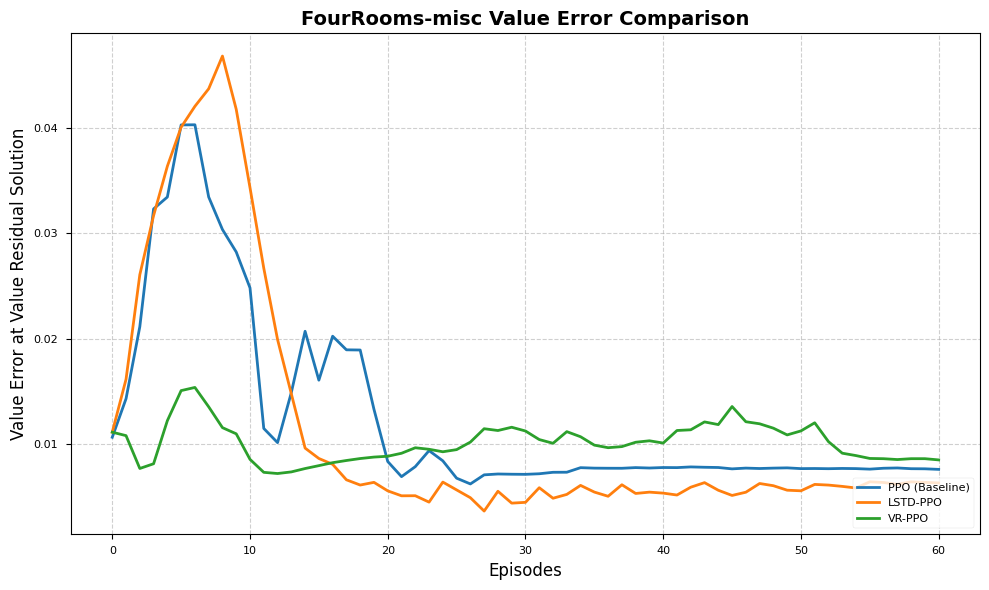

In [31]:
runs = {
    "PPO (Baseline)": metrics['VR_uniform_VE'],
    "LSTD-PPO": lstd_ppo_metrics['VR_uniform_VE'],
    "VR-PPO": vr_ppo_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")


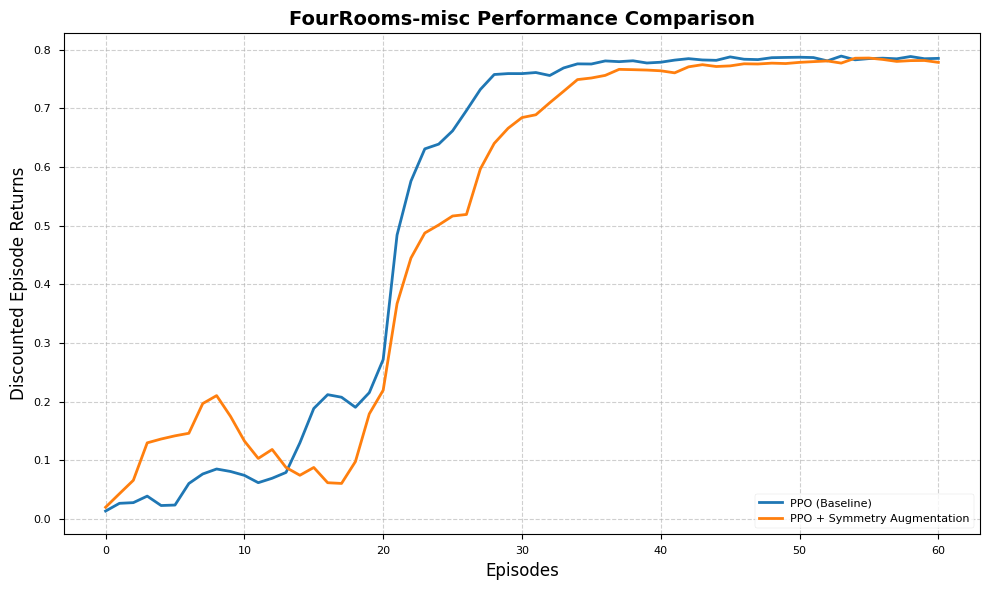

In [35]:
# results/ppo_symmetry_augmentation/20260511_161729/FourRooms-misc/Weightedconfig


ppoconfig, metrics = load_run_data("ppo/20260510_092335", 'FourRooms-misc', 'results')
ppoconfig, symmetrics = load_run_data("ppo_symmetry_augmentation/20260511_161729", 'FourRooms-misc', 'results')

runs = {
    "PPO (Baseline)": metrics['returned_discounted_episode_returns'],
    "PPO + Symmetry Augmentation": symmetrics['returned_discounted_episode_returns']
    
}

plot_rl_results(runs, title="FourRooms-misc Performance Comparison")